# One dimensional dummy problem

In this section the goal will be to solve the 1 dimensional dummy problem for a first step to pressure gradients

\begin{equation}
\begin{aligned}
\rho \partial_t v &=-RT\partial_x\rho+\mu\partial_x^2 v \\
\partial_t\rho&=-(\partial_x \rho)v-\rho (\partial_x v)
\end{aligned}
\end{equation}

under IC:

\begin{equation}
\left\{ \begin{aligned}
\rho(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}

and BC:
\begin{equation}
\left\{\begin{aligned}
p_{\text{tot}} = RT\rho+\frac{1}{2}\rho v^2 &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
v(L,t) &= 0
\end{aligned}\right.
\end{equation}

In [ ]:
using OrdinaryDiffEq, MethodOfLines, DomainSets, ModelingToolkit;

## Definitions

In [ ]:
# Parameters, variables, and derivatives
@parameters t x
@variables ρ(..) v(..) # ptot(..)

# definitions of derivatives
Dt = Differential(t)
Dx = Differential(x)
Dxx = Differential(x)^2

# constants
R = 1.0
T = 1.0
μ = 1.0

# PDE and definition for total pressure
eq = [

    # momentum
    Dt(v(t, x)) ~ (
        -R*T*Dx(ρ(t, x)) +
        μ*Dxx(v(t, x))
    ) / ρ(t, x),

    # continuity
    Dt(ρ(t, x)) ~
        -Dx(ρ(t, x))*v(t, x)
        -ρ(t, x)*Dx(v(t, x)),

    # total pressure definition
    # ptot(t,x) ~
    #     R*T*ρ(t,x) +
    #     0.5*ρ(t,x)*v(t,x)^2
]

# Boundary conditions
bcs = [

    # initial conditions
    ρ(0, x) ~ 1.0,
    v(0, x) ~ 0.0,

    # total-pressure inlet BC
    ρ(t,0) ~ (
        2.0 - exp(-10.0*t)
    ) / (
        R*T + 0.5*v(t,0)^2
    ),

    # velocity BCs
    Dx(v(t,0)) ~ 0.0,
    v(t,1) ~ 0.0
]

# Space and time domains
domains = [
    t ∈ Interval(0.0, 8.0),
    x ∈ Interval(0.0, 1.0)
]

2-element Vector{Symbolics.VarDomainPairing}:
 Symbolics.VarDomainPairing(t, 0.0 .. 8.0)
 Symbolics.VarDomainPairing(x, 0.0 .. 1.0)

## PDE

In [9]:
# PDE system
@named pdesys = PDESystem(
    eq, 
    bcs, 
    domains, 
    [t, x], [ρ(t, x), v(t, x)]
)

PDESystem
Equations: Equation[Differential(t, 1)(v(t, x)) ~ (Differential(x, 2)(v(t, x)) - Differential(x, 1)(ρ(t, x))) / ρ(t, x), Differential(t, 1)(ρ(t, x)) ~ -ρ(t, x)*Differential(x, 1)(v(t, x)) - Differential(x, 1)(ρ(t, x))*v(t, x)]
Boundary Conditions: Equation[ρ(0, x) ~ 1.0, v(0, x) ~ 0.0, ρ(t, 0) ~ (2.0 - exp(-10.0t)) / (1.0 + 0.5(v(t, 0)^2)), Differential(x, 1)(v(t, 0)) ~ 0.0, v(t, 1) ~ 0.0]
Domain: Symbolics.VarDomainPairing[Symbolics.VarDomainPairing(t, 0.0 .. 8.0), Symbolics.VarDomainPairing(x, 0.0 .. 1.0)]
Dependent Variables: Num[ρ(t, x), v(t, x)]
Independent Variables: Num[t, x]
Parameters: SciMLBase.NullParameters()
Default Parameter ValuesModelingToolkitBase.AtomicArrayDict{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}, Dict{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}, SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}}}()

In [10]:
# Method of lines discretization
dx = .02
order = 2
discretization = MOLFiniteDifference([x => dx], t)

# Convert the PDE problem into an ODE problem
prob = discretize(pdesys, discretization);

In [11]:
# Solve ODE problem
using OrdinaryDiffEq
sol = solve(prob, Tsit5(), saveat = 0.1)

PDESolution:
  Return Code:
    Success
  Dependent variables:
    v(t, x): (81, 51) sized solution
    ρ(t, x): (81, 51) sized solution
  Domain:
    t ∈ (0.0, 8.0) with 81 points, step size 0.1
    x ∈ (0.0, 1.0) with 51 points, step size 0.02
  From system:
    Equations:
    Boundary/Initial Conditions:


L"\begin{align}
\frac{ - \frac{\mathrm{d}^{2}}{\mathrm{d}x^{2}} ~ v\left( t, x \right) + \frac{\mathrm{d}}{\mathrm{d}x} ~ \rho\left( t, x \right)}{\rho\left( t, x \right)} + \frac{\mathrm{d}}{\mathrm{d}t} ~ v\left( t, x \right) &= 0 \\
\frac{\mathrm{d}}{\mathrm{d}t} ~ \rho\left( t, x \right) + \rho\left( t, x \right) ~ \frac{\mathrm{d}}{\mathrm{d}x} ~ v\left( t, x \right) + \frac{\mathrm{d}}{\mathrm{d}x} ~ \rho\left( t, x \right) ~ v\left( t, x \right) &= 0
\end{align}
"

L"\begin{align}
\rho\left( 0, x \right) &= 1 \\
v\left( 0, x \right) &= 0 \\
\rho\left( t, 0 \right) &= \frac{2 - e^{ - 10 ~ t}}{1 + 0.5 ~ \left( v\left( t, 0 \right) \right)^{2}} \\
\frac{\mathrm{d}}{\mathrm{d}x} ~ v\left( t, 0 \right) &= 0 \\
v\left( t, 1 \right) &= 0
\end{align}
"

## Plotting/animating

In [15]:
# Plot results and compare with exact solution
discrete_x = sol[x];
discrete_t = sol[t];
sol_ρ = sol[ρ(t, x)];
sol_v = sol[v(t, x)];


folder = "d. one dimensional total pressure";
mkpath(folder);

In [16]:
# Used for plotting
using Plots

┌ Info: Saved animation to c:\Users\noudh\uni\MEP\3. rho time derivative\d. one dimensional total pressure\flow.gif
└ @ Plots C:\Users\noudh\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\3. rho time derivative\\d. one dimensional total pressure\\flow.gif")
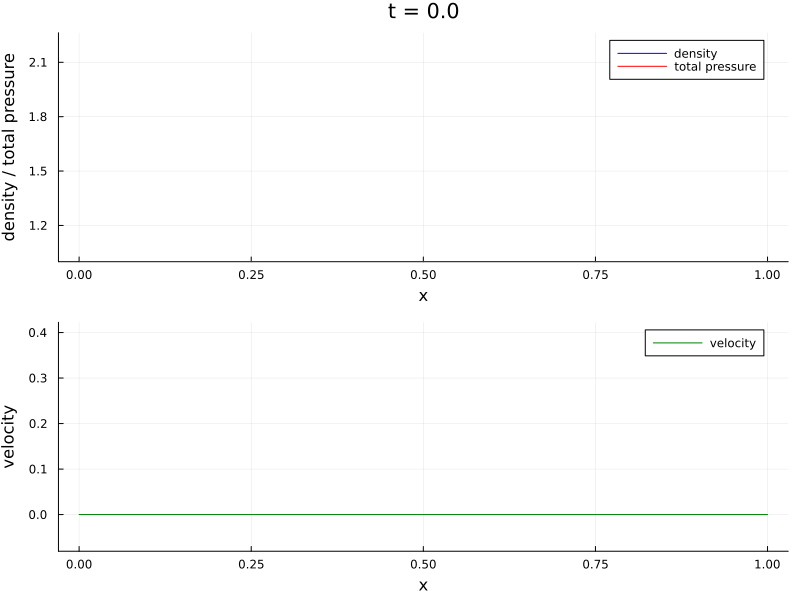

In [ ]:
# total pressure
sol_ptot = R .* T .* sol_ρ .+ 0.5 .* sol_ρ .* sol_v.^2

# limits
ρmin = minimum(sol_ρ)
ρmax = maximum(sol_ρ)

ptmin = minimum(sol_ptot)
ptmax = maximum(sol_ptot)

vmin = minimum(sol_v)
vmax = maximum(sol_v)

left_min = min(ρmin, ptmin)
left_max = max(ρmax, ptmax)

anim = @animate for k in 1:length(discrete_t)

    # top plot: density + total pressure
    p1 = plot(
        discrete_x,
        sol_ρ[k, :],

        label = "density",
        color = :blue,

        xlabel = "x",
        ylabel = "density / total pressure",

        ylims = (left_min, left_max),

        title = "t = $(round(discrete_t[k], digits=3))",

        legend = :topright
    )

    plot!(
        p1,
        discrete_x,
        sol_ptot[k, :],

        label = "total pressure",
        color = :red
    )

    # bottom plot: velocity
    p2 = plot(
        discrete_x,
        sol_v[k, :],

        label = "velocity",
        color = :green,

        xlabel = "x",
        ylabel = "velocity",

        ylims = (vmin, vmax),

        legend = :topright
    )

    # combine vertically
    plot(
        p1,
        p2,

        layout = (2,1),
        size = (800,600)
    )

end

gif(anim, joinpath(folder, "flow.gif"), fps = 8)

┌ Info: Saved animation to c:\Users\noudh\uni\MEP\3. rho time derivative\a. one dimensional\v.gif
└ @ Plots C:\Users\noudh\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\3. rho time derivative\\a. one dimensional\\v.gif")
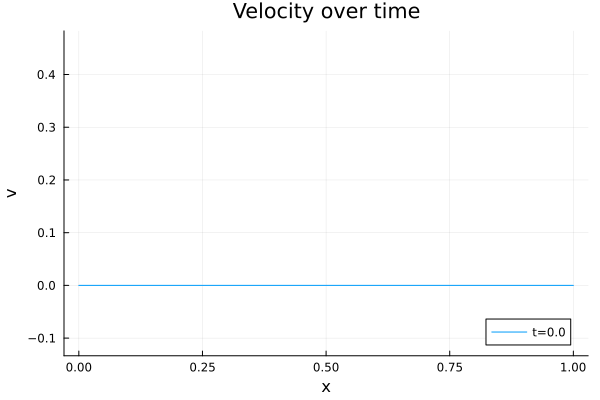

In [13]:
ymin = minimum(sol_v)
ymax = maximum(sol_v)

anim = @animate for k in 1:length(discrete_t)
    plot(
        discrete_x, 
        sol_v[k, :], 
        title = "Velocity over time", 
        ylims = (ymin, ymax), 
        ylabel = "v",
        xlabel = "x",
        label = "t=$(discrete_t[k])",
        legend = :bottomright
    )
end

gif(anim, joinpath(folder, "v.gif"), fps = 8)

### Ugly plots below

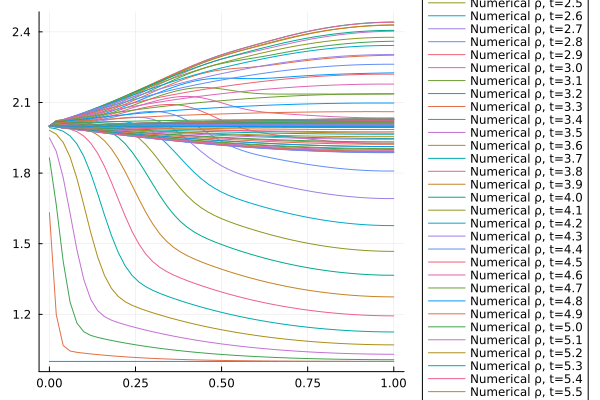

In [14]:
plt = plot(legend = :outerright)
for i in eachindex(discrete_t)
    plot!(discrete_x, sol_ρ[i, :], label = "Numerical ρ, t=$(discrete_t[i])")
end
plt

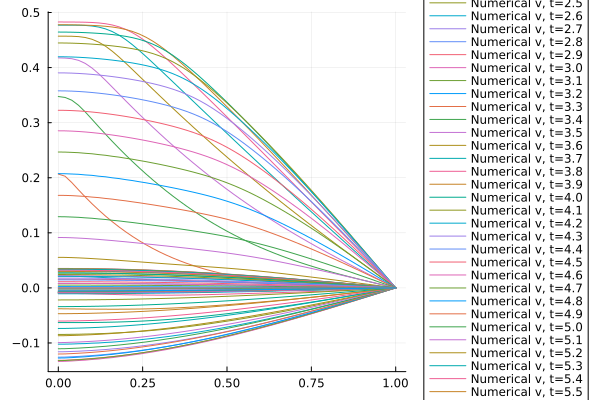

In [15]:
plt = plot(legend = :outerright)
for i in eachindex(discrete_t)
    plot!(discrete_x, sol_v[i, :], label = "Numerical v, t=$(discrete_t[i])")
end
plt